## 1. IMPORTING NECESSARY LIBRARIES

In [117]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
import joblib

In [118]:
pd.set_option("display.max_columns",None)

## 2. DATA LOADING AND INITIAL EXPLORATION

In [119]:
df = pd.read_csv("/content/German_credit_data_aug.csv")

In [120]:
print(f"No of rows: {df.shape[0]} and No of columns: {df.shape[1]}")

No of rows: 10000 and No of columns: 11


In [121]:
print("Data types:\n", df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        10000 non-null  int64 
 1   Age               10000 non-null  int64 
 2   Sex               10000 non-null  object
 3   Job               10000 non-null  int64 
 4   Housing           10000 non-null  object
 5   Saving accounts   9817 non-null   object
 6   Checking account  9606 non-null   object
 7   Credit amount     10000 non-null  int64 
 8   Duration          10000 non-null  int64 
 9   Purpose           10000 non-null  object
 10  Risk              10000 non-null  object
dtypes: int64(5), object(6)
memory usage: 859.5+ KB
Data types:
 None


In [122]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64


In [123]:
## First few rows of the data
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [124]:
## Dropping unnecessary columns
df.drop(['Unnamed: 0'],axis=1,inplace=True)

In [125]:
# No of duplicate rows
print("No of duplicated row: ",df.duplicated().sum())

No of duplicated row:  1


In [126]:
## Dropping duplicate rows
df.drop_duplicates(inplace=True)

## 3. DATA CLEANING AND PREPROCESSING

In [127]:
## Handle missing values - dropping rows with missing data
df = df.dropna().reset_index(drop=True)
print("Shape of dataset after dropping null values:",df.shape)

Shape of dataset after dropping null values: (9521, 10)


## 4. EXPLORATORY DATA ANALYSIS (EDA)

### 4.1 Statistical Summary

In [128]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,9521.0,NaN,NaN,NaN,35.578931,8.999305,19.0,29.0,35.0,42.0,75.0
Sex,9521,2,male,6497,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,9521.0,NaN,NaN,NaN,1.902951,0.605327,0.0,2.0,2.0,2.0,3.0
Housing,9521,3,own,6847,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,9521,4,little,6980,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,9521,3,little,4335,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,9521.0,NaN,NaN,NaN,3368.908098,2141.459636,250.0,1712.0,3217.0,4770.0,18424.0
Duration,9521.0,NaN,NaN,NaN,20.917551,9.504479,4.0,14.0,21.0,27.0,72.0
Purpose,9521,8,car,3187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Risk,9521,2,good,6613,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 4.2 Numerical Features Analysis

In [129]:
num_features = ['Age', 'Credit amount', 'Duration']

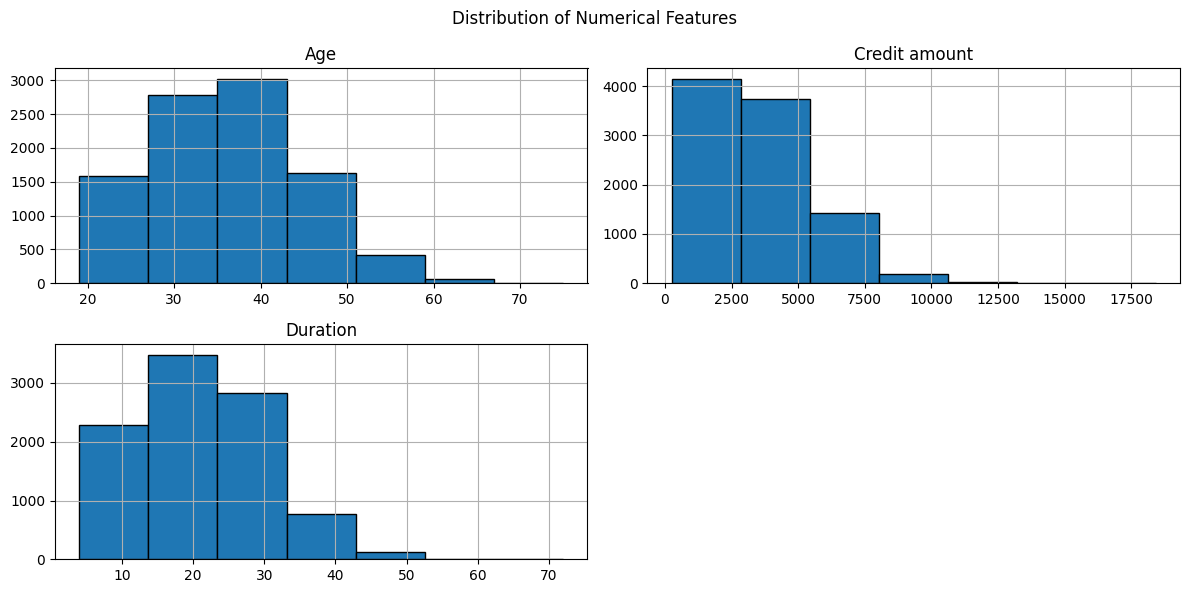

In [130]:
# Histograms
df[num_features].hist(bins=7, edgecolor="black", figsize=(12, 6))
plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

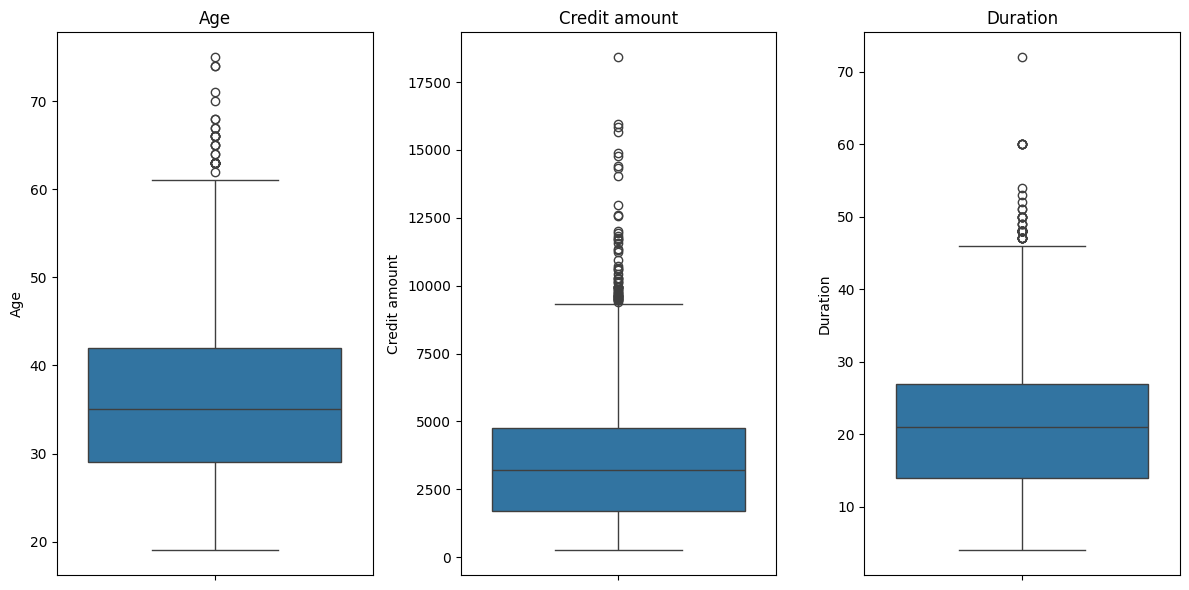

In [131]:
# Boxplots
plt.figure(figsize=(12, 6))
for i, col in enumerate(num_features):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [132]:
df.query("Duration >= 60")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


### 4.3 Categorical Features Analysis


In [133]:
cat_features = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose', 'Risk']

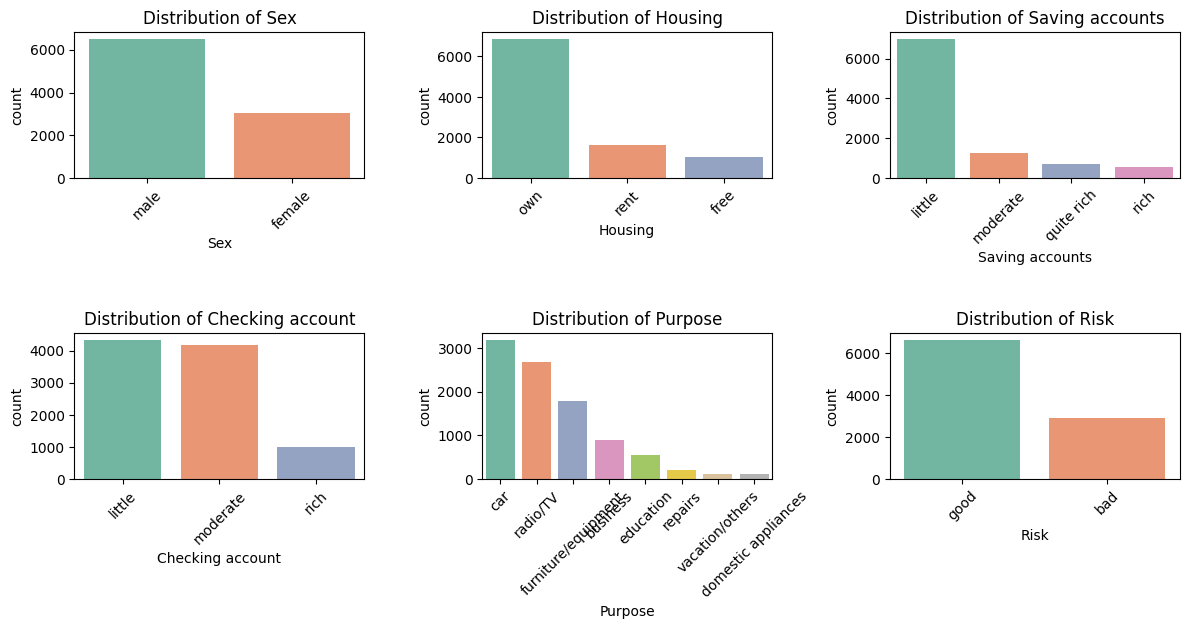

In [134]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(cat_features):
    plt.subplot(3, 3, i + 1)
    sns.countplot(data=df, x=col, palette="Set2", order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.4 Correlation Analysis

In [135]:
corr = df[['Age','Job','Credit amount','Duration']].corr()
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.011240,0.030156,-0.008029
Job,0.011240,1.000000,0.035841,0.021961
Credit amount,0.030156,0.035841,1.000000,0.063571
Duration,-0.008029,0.021961,0.063571,1.000000


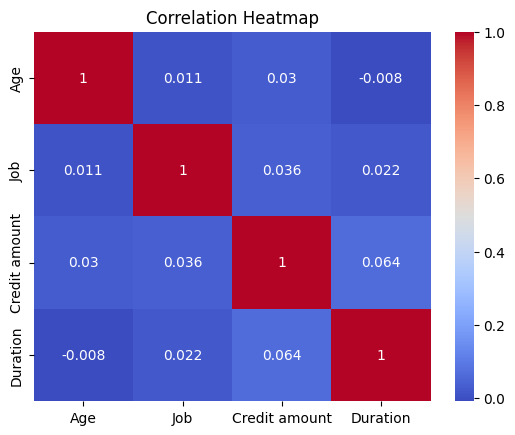

In [136]:
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### 4.5 Group Analysis

In [137]:
df.groupby("Job")['Credit amount'].mean()  ## as the job count increases the credit amount increases

,Credit amount
Job,
0,3187.290909
1,3277.704219
2,3363.697282
3,3551.351415


In [138]:
df.groupby('Sex')['Credit amount'].mean()

,Credit amount
Sex,
female,3281.263889
male,3409.701708


In [139]:
pd.pivot_table(df,values="Credit amount",index="Housing",columns="Purpose")

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,3360.147059,3583.135359,3950.090909,3331.816901,3342.095000,3306.651515,3910.411765,3783.352941
own,3353.134400,3390.593641,3350.852941,3311.539846,3383.306667,3373.844130,3311.993151,3771.555556
rent,3435.723926,3273.472590,3474.833333,3480.494949,3280.179487,3179.594104,3723.024390,2540.714286


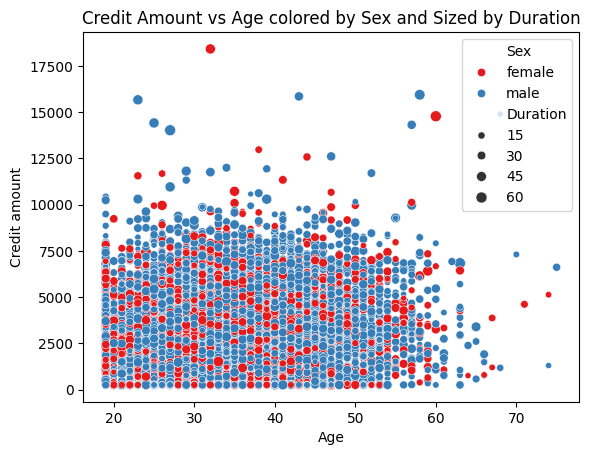

In [140]:
## Scatter Plot
sns.scatterplot(data=df, x="Age", y="Credit amount", hue="Sex", size="Duration", palette="Set1")
plt.title("Credit Amount vs Age colored by Sex and Sized by Duration")
plt.show()


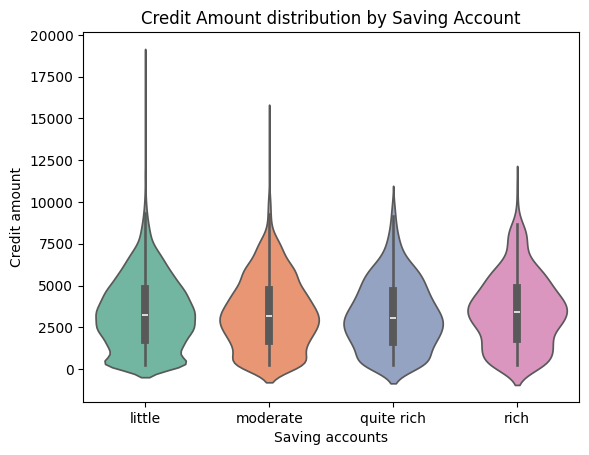

In [141]:
## Violin Plot
sns.violinplot(data=df, x="Saving accounts", y="Credit amount", palette="Set2")
plt.title("Credit Amount distribution by Saving Account")
plt.show()

### 4.6 Target Variable Analysis

In [142]:
df['Risk'].value_counts(normalize=100)* 100

,proportion
Risk,
good,69.45699
bad,30.54301


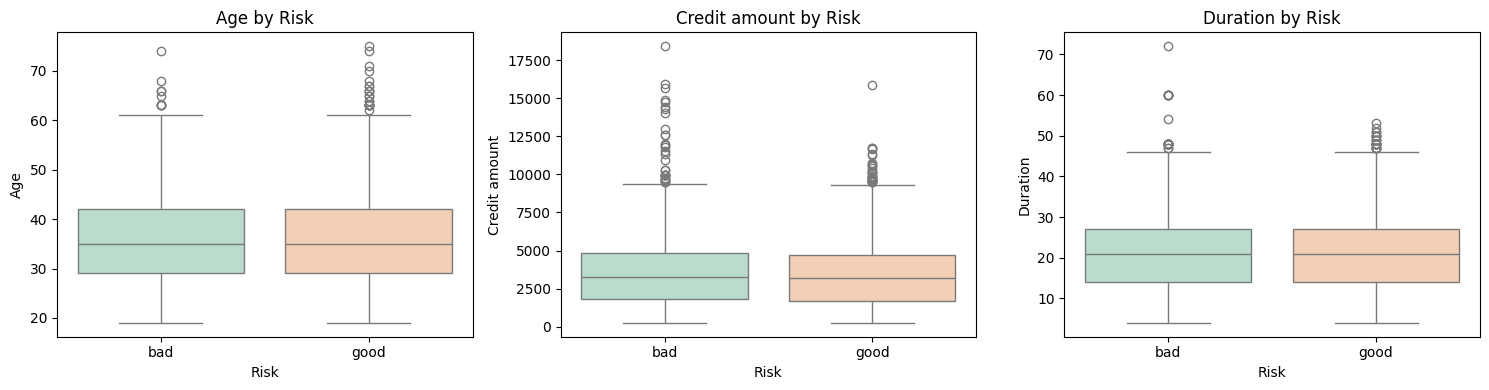

In [143]:
## Boxplot
plt.figure(figsize=(15, 4))
for i, col in enumerate(num_features):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(data=df, x="Risk", y=col, palette="Pastel2")
    plt.title(f"{col} by Risk")
plt.tight_layout()
plt.show()

In [144]:
## Risk by Features
df.groupby("Risk")[['Age','Credit amount',"Duration"]].mean()

,Age,Credit amount,Duration
Risk,,,
bad,35.656121,3481.448418,20.977304
good,35.544987,3319.419628,20.891275


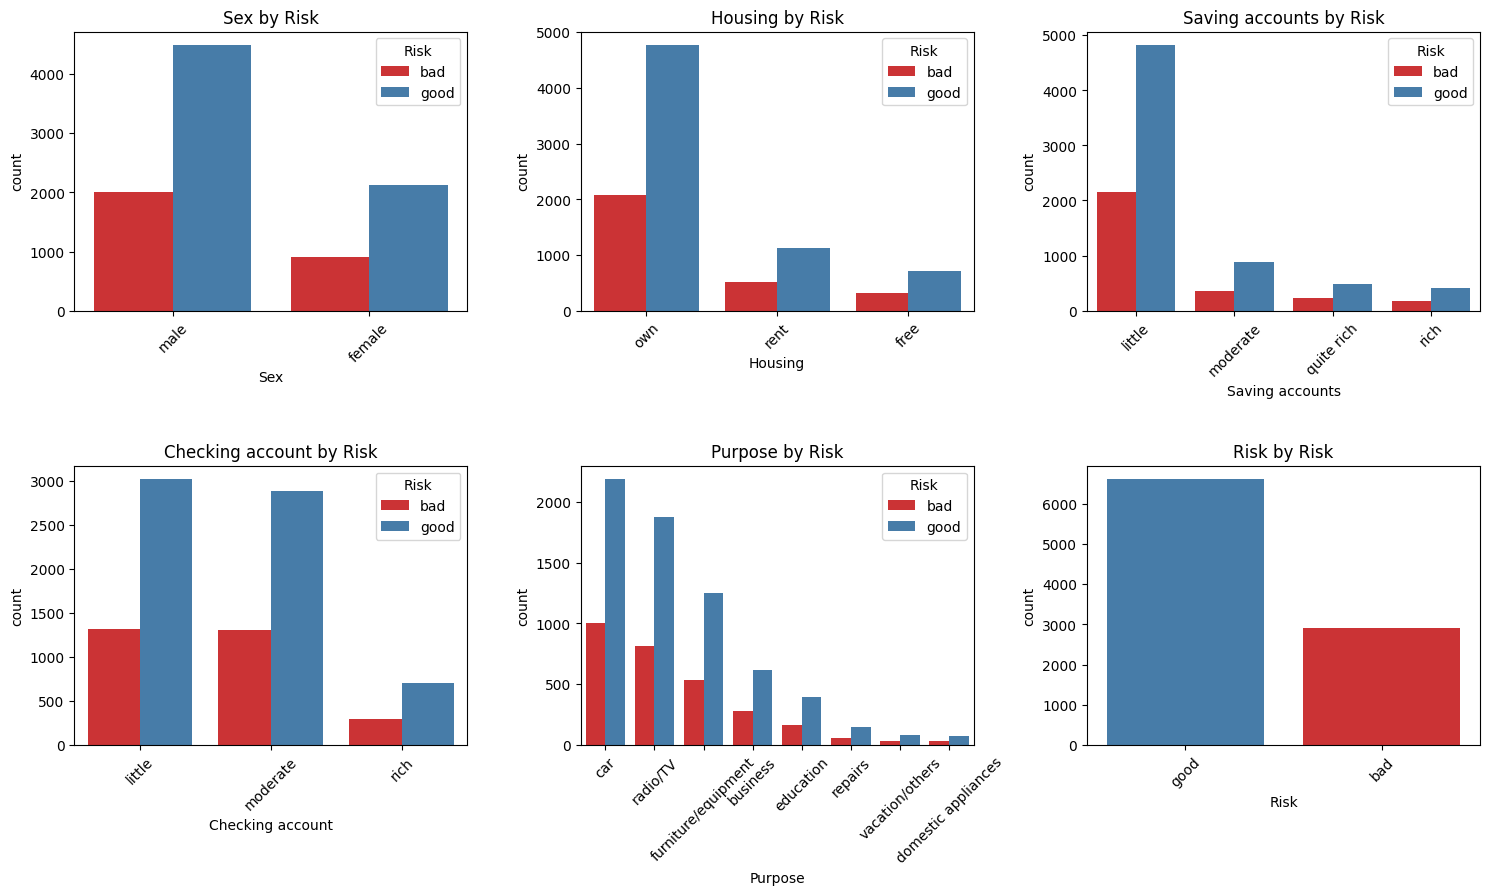

In [145]:
## Countplot
plt.figure(figsize=(15, 12))
for i, col in enumerate(cat_features):
    plt.subplot(3, 3, i + 1)
    sns.countplot(data=df, x=col, hue="Risk", palette="Set1", order=df[col].value_counts().index)
    plt.title(f"{col} by Risk")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. FEATURE ENGINEERING

In [146]:
## Defining features and target
features = ['Age', "Sex", "Job", "Housing", "Saving accounts", "Checking account", "Credit amount", "Duration"]
target = "Risk"

In [147]:
## Create model dataframe
df_model = df[features + [target]].copy()

In [148]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


## 6. ENCODING

In [149]:
## Identifying categorical columns (excluding target)
cat_cols = df_model.select_dtypes(include="object").columns.drop("Risk")

In [150]:
le_dict = {}

for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le
    # Save encoder for deployment
    joblib.dump(le, f"{col}_encoder.pkl")

In [151]:
## Encoding target variable
le = LabelEncoder()
df_model[target] = le.fit_transform(df_model[target])
joblib.dump(le, "target_encoder.pkl")

['target_encoder.pkl']

## 7.  TRAIN-TEST SPLIT


In [152]:
## Splitting data with stratification
X = df_model.iloc[:, 0:8]
y = df_model.iloc[:, -1]

# Split data with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=1
)

In [153]:
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (7616, 8)
Test set shape: (1905, 8)


## 7. MODEL TRAINING FUNCTIONS

In [154]:
def train_model(model,param_grid,X_train,y_train,X_test,y_test):
  grid = GridSearchCV(model,param_grid, cv=5, scoring="accuracy",n_jobs=-1)
  grid.fit(X_train,y_train)
  best_model = grid.best_estimator_
  y_pred = best_model.predict(X_test)
  acc = accuracy_score(y_test,y_pred)
  return best_model, acc, grid.best_params_

### 7.1 MODEL 1: DECISION TREE

In [155]:
dt = DecisionTreeClassifier(random_state=1, class_weight="balanced")
dt_param_grid = {
    "max_depth":[3,5,7,10,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

In [156]:
best_dt, acc_dt, param_dt = train_model(dt,dt_param_grid,X_train,y_train,X_test,y_test)

In [157]:
param_dt

{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

In [158]:
acc_dt

0.5837270341207349

### 7.2 Model 2: Random Forest Classifier

In [159]:
rfc = RandomForestClassifier(random_state=1,class_weight="balanced")

In [160]:
rfc_param_grid = {
    "n_estimators": [100,200],
    "max_depth":[5,7,10,None],
    "min_samples_split": [2,5,100],
    "min_samples_leaf":[1,2,4]
}

In [161]:
best_rfc, acc_rfc, param_rfc = train_model(rfc,rfc_param_grid,X_train,y_train,X_test,y_test)

In [162]:
acc_rfc

0.6614173228346457

### 7.3 MODEL 2: Extra Tree Classifier

In [163]:
etc = ExtraTreesClassifier(random_state=1,class_weight="balanced",n_jobs=-1)

In [164]:
etc_param_grid = {
    "n_estimators": [100,200],
    "max_depth":[5,7,10,None],
    "min_samples_split": [2,5,100],
    "min_samples_leaf":[1,2,4]
}

In [165]:
best_etc, acc_etc, param_etc = train_model(etc,etc_param_grid,X_train,y_train,X_test,y_test)

In [166]:
acc_etc

0.6435695538057743

### 7.4 MODEL 3: XG Boost Classifier

In [167]:
xgb = XGBClassifier(random_state=1, scale_pos_weight= (y_train==0).sum()/(y_train==1).sum(), eval_metric="logloss")

In [168]:
xgb_param_grid = {
    "n_estimators": [100,200],
    "max_depth":[3,5,7],
    "learning_rate":[0.01,0.1,0.2],
    "subsample":[0.7,1],
    "colsample_bytree":[0.7,1]

}

In [169]:
best_xgb, acc_xgb, param_xgb = train_model(xgb,xgb_param_grid,X_train,y_train,X_test,y_test)

In [170]:
acc_xgb

0.573228346456693

In [174]:
joblib.dump(best_rfc,"RFC_credit_model.pkl")

['RFC_credit_model.pkl']